# 🚗 Car Price Prediction using Machine Learning (Version 2)

## 📌 Project Overview

This project predicts the resale price of used cars using Machine Learning techniques.

The notebook covers the complete machine learning workflow from data preprocessing to deployment.

---

## 🎯 Objectives

- Load and understand the dataset
- Clean and preprocess the data
- Perform Exploratory Data Analysis (EDA)
- Engineer useful features
- Train multiple regression models
- Compare model performance
- Tune the best-performing model
- Evaluate the final model
- Save the model and preprocessing artifacts
- Prepare files for Streamlit deployment

---

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Plotly
- Joblib

---

## 📂 Dataset

**Source:** CarDekho Used Car Dataset

### Features

- Car_Name
- Year
- Selling_Price
- Present_Price
- Kms_Driven
- Fuel_Type
- Seller_Type
- Transmission
- Owner

---

## 🤖 Target Variable

**Selling_Price**

---

## 🚀 Workflow

1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Data Preprocessing
7. Model Training
8. Hyperparameter Tuning
9. Model Evaluation
10. Save Model
11. Streamlit Deployment

---

👨‍💻 **Developed by:** Gaurav Eknath Kumbhar

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Plot Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("=" * 60)
print("🚗 Car Price Prediction V2")
print("=" * 60)
print("All libraries imported successfully.")

🚗 Car Price Prediction V2
All libraries imported successfully.


In [3]:
# ==========================================================
# Create Project Folders
# ==========================================================

folders = [
    "models",
    "assets",
    "reports",
    "plots"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("car data.csv")

print("\nDataset loaded successfully.")
print(f"Shape: {df.shape}")

df.head()

Project folders created successfully.

Dataset loaded successfully.
Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names")
print("-" * 60)

for col in df.columns:
    print(col)

display(df.head())

display(df.tail())

df.sample(5, random_state=42)

DATASET OVERVIEW
Rows    : 301
Columns : 9

Column Names
------------------------------------------------------------
Car_Name
Year
Selling_Price
Present_Price
Driven_kms
Fuel_Type
Selling_type
Transmission
Owner


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
177,Honda Activa 125,2016,0.35,0.57,24000,Petrol,Individual,Automatic,0
289,city,2016,10.11,13.60,10980,Petrol,Dealer,Manual,0
228,verna,2012,4.95,9.40,60000,Diesel,Dealer,Manual,0
198,Bajaj Discover 125,2011,0.15,0.57,35000,Petrol,Individual,Manual,1
60,corolla altis,2013,6.95,18.61,40001,Petrol,Dealer,Manual,0


In [5]:
# ==========================================================
# Dataset Information
# ==========================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

df.info()

print("\n")

display(df.describe().T)

print("\nData Types\n")

display(pd.DataFrame({

    "Column": df.columns,

    "Data Type": df.dtypes.astype(str),

    "Missing Values": df.isnull().sum(),

    "Unique Values": df.nunique()

}))

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB




,count,mean,std,min,25%,50%,75%,max
Year,301.0,2013.627907,2.891554,2003.00,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,4.661296,5.082812,0.10,0.9,3.6,6.0,35.0
Present_Price,301.0,7.628472,8.642584,0.32,1.2,6.4,9.9,92.6
Driven_kms,301.0,36947.205980,38886.883882,500.00,15000.0,32000.0,48767.0,500000.0
Owner,301.0,0.043189,0.247915,0.00,0.0,0.0,0.0,3.0



Data Types



,Column,Data Type,Missing Values,Unique Values
Car_Name,Car_Name,object,0,98
Year,Year,int64,0,16
Selling_Price,Selling_Price,float64,0,156
Present_Price,Present_Price,float64,0,148
Driven_kms,Driven_kms,int64,0,206
Fuel_Type,Fuel_Type,object,0,3
Selling_type,Selling_type,object,0,2
Transmission,Transmission,object,0,2
Owner,Owner,int64,0,3


,Missing Values,Percentage
Car_Name,0,0.0
Year,0,0.0
Selling_Price,0,0.0
Present_Price,0,0.0
Driven_kms,0,0.0
Fuel_Type,0,0.0
Selling_type,0,0.0
Transmission,0,0.0
Owner,0,0.0


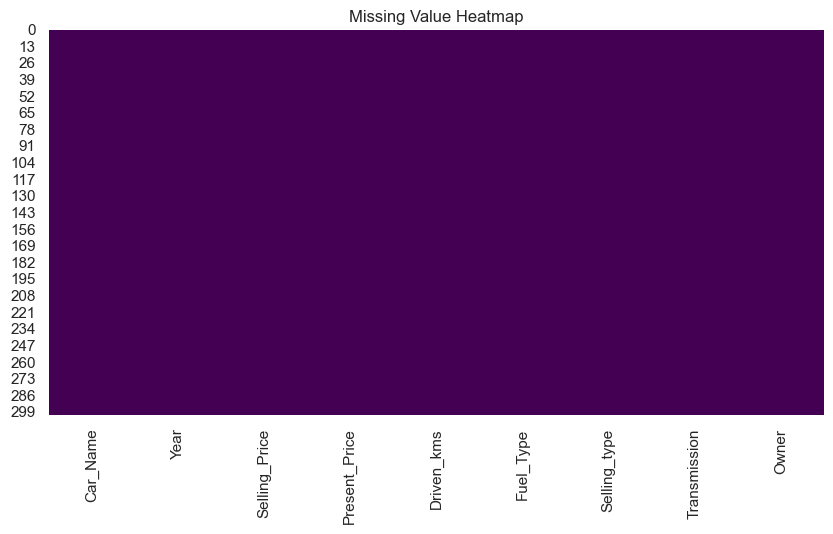


Total Missing Values : 0


In [6]:
# ==========================================================
# Missing Values
# ==========================================================

missing = pd.DataFrame({

    "Missing Values": df.isnull().sum(),

    "Percentage": (
        df.isnull().sum() / len(df)
    ) * 100

})

display(missing)

plt.figure(figsize=(10,5))

sns.heatmap(

    df.isnull(),

    cbar=False,

    cmap="viridis"

)

plt.title("Missing Value Heatmap")

plt.show()

print("\nTotal Missing Values :", df.isnull().sum().sum())

In [7]:
# ==========================================================
# Duplicate Records
# ==========================================================

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

if duplicates > 0:

    df = df.drop_duplicates()

    print("Duplicates removed successfully.")

else:

    print("No duplicate records found.")

print("\nNew Shape :", df.shape)

Duplicate Records : 2
Duplicates removed successfully.

New Shape : (299, 9)


In [8]:
# ==========================================================
# Clean Column Names
# ==========================================================

df.columns = (

    df.columns

    .str.strip()

    .str.replace(" ", "_")

)

print(df.columns.tolist())

display(df.head())

['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


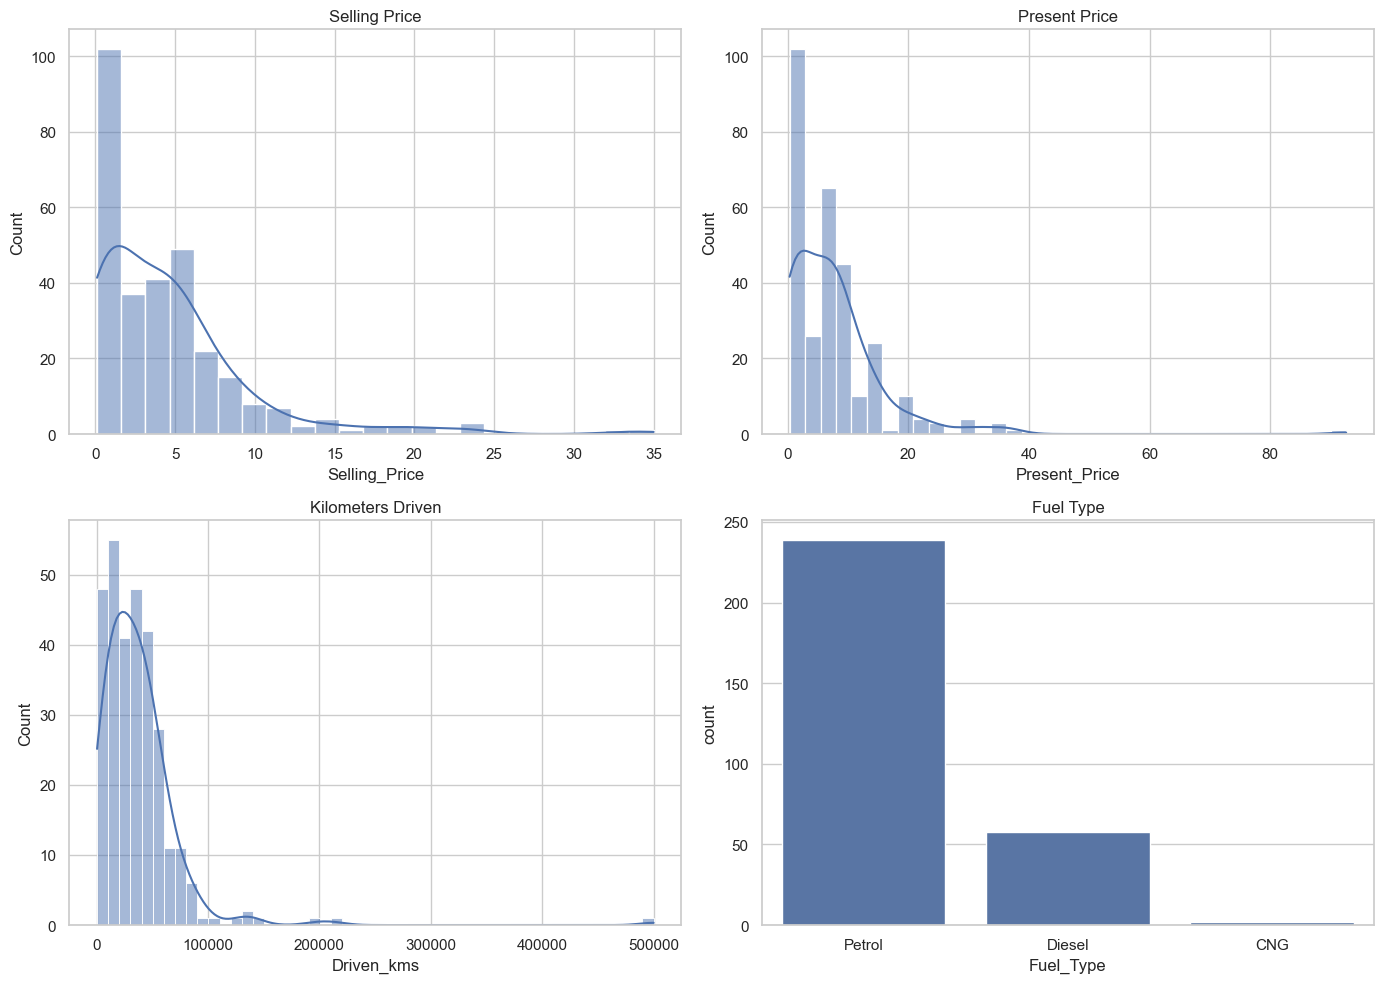

In [10]:
# ==========================================================
# Exploratory Data Analysis
# ==========================================================

fig, ax = plt.subplots(

    2,

    2,

    figsize=(14,10)

)

sns.histplot(

    df["Selling_Price"],

    kde=True,

    ax=ax[0,0]

)

ax[0,0].set_title("Selling Price")

sns.histplot(

    df["Present_Price"],

    kde=True,

    ax=ax[0,1]

)

ax[0,1].set_title("Present Price")

sns.histplot(

    df["Driven_kms"],

    kde=True,

    ax=ax[1,0]

)

ax[1,0].set_title("Kilometers Driven")

sns.countplot(

    x=df["Fuel_Type"],

    ax=ax[1,1]

)

ax[1,1].set_title("Fuel Type")

plt.tight_layout()

plt.show()

In [11]:
# ==========================================================
# Feature Engineering
# ==========================================================

CURRENT_YEAR = 2025

df["Car_Age"] = CURRENT_YEAR - df["Year"]

# Remove unnecessary column
df.drop("Year", axis=1, inplace=True)

# Car_Name is not useful for prediction
df.drop("Car_Name", axis=1, inplace=True)

display(df.head())

print("\nUpdated Shape :", df.shape)

print("\nColumns")

print(df.columns.tolist())

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,11



Updated Shape : (299, 8)

Columns
['Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']


In [12]:
# ==========================================================
# Encode Categorical Features
# ==========================================================

categorical_columns = [
    "Fuel_Type",
    "Selling_type",
    "Transmission"
]

label_encoders = {}

for column in categorical_columns:

    encoder = LabelEncoder()

    df[column] = encoder.fit_transform(df[column])

    label_encoders[column] = encoder

print("Categorical features encoded successfully.\n")

for col, encoder in label_encoders.items():

    print(f"{col}")

    mapping = dict(zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    ))

    print(mapping)
    print("-" * 40)

display(df.head())

Categorical features encoded successfully.

Fuel_Type
{'CNG': np.int64(0), 'Diesel': np.int64(1), 'Petrol': np.int64(2)}
----------------------------------------
Selling_type
{'Dealer': np.int64(0), 'Individual': np.int64(1)}
----------------------------------------
Transmission
{'Automatic': np.int64(0), 'Manual': np.int64(1)}
----------------------------------------


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,11
1,4.75,9.54,43000,1,0,1,0,12
2,7.25,9.85,6900,2,0,1,0,8
3,2.85,4.15,5200,2,0,1,0,14
4,4.60,6.87,42450,1,0,1,0,11


In [13]:
# ==========================================================
# Feature Selection
# ==========================================================

X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

feature_columns = X.columns.tolist()

print("Feature Columns")

print(feature_columns)

print()

print("Target Variable")

print(y.name)

print()

print("Shape of X :", X.shape)

print("Shape of y :", y.shape)

Feature Columns
['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']

Target Variable
Selling_Price

Shape of X : (299, 7)
Shape of y : (299,)


In [14]:
# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

print()

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Samples : 239
Testing Samples : 60

Training Shape : (239, 7)
Testing Shape : (60, 7)


In [15]:
# ==========================================================
# Linear Regression
# ==========================================================

linear_model = LinearRegression()

linear_model.fit(

    X_train,

    y_train

)

linear_pred = linear_model.predict(X_test)

linear_r2 = r2_score(

    y_test,

    linear_pred

)

print("Linear Regression R² Score")

print(round(linear_r2,4))

Linear Regression R² Score
0.741


In [16]:
# ==========================================================
# Decision Tree Regressor
# ==========================================================

tree_model = DecisionTreeRegressor(

    random_state=42

)

tree_model.fit(

    X_train,

    y_train

)

tree_pred = tree_model.predict(X_test)

tree_r2 = r2_score(

    y_test,

    tree_pred

)

print("Decision Tree R² Score")

print(round(tree_r2,4))

Decision Tree R² Score
0.8252


In [17]:
# ==========================================================
# Random Forest
# ==========================================================

rf_model = RandomForestRegressor(

    n_estimators=300,

    random_state=42

)

rf_model.fit(

    X_train,

    y_train

)

rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(

    y_test,

    rf_pred

)

print("Random Forest R² Score")

print(round(rf_r2,4))

Random Forest R² Score
0.5361


In [18]:
# ==========================================================
# Extra Trees Regressor
# ==========================================================

extra_model = ExtraTreesRegressor(

    n_estimators=300,

    random_state=42

)

extra_model.fit(

    X_train,

    y_train

)

extra_pred = extra_model.predict(X_test)

extra_r2 = r2_score(

    y_test,

    extra_pred

)

print("Extra Trees R² Score")

print(round(extra_r2,4))

Extra Trees R² Score
0.8028


In [19]:
# ==========================================================
# Gradient Boosting
# ==========================================================

gb_model = GradientBoostingRegressor(

    random_state=42

)

gb_model.fit(

    X_train,

    y_train

)

gb_pred = gb_model.predict(X_test)

gb_r2 = r2_score(

    y_test,

    gb_pred

)

print("Gradient Boosting R² Score")

print(round(gb_r2,4))

Gradient Boosting R² Score
0.6758


,Model,R2 Score
1,Decision Tree,0.825168
3,Extra Trees,0.802802
0,Linear Regression,0.740993
4,Gradient Boosting,0.675802
2,Random Forest,0.536147


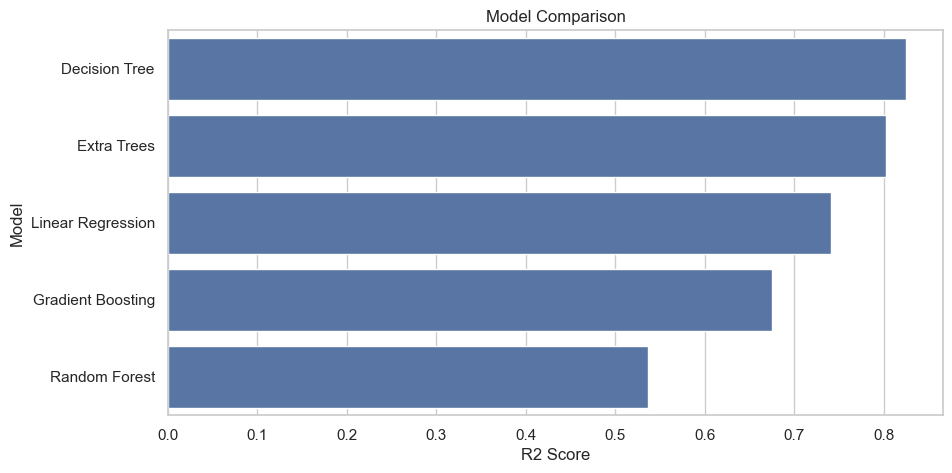

In [20]:
# ==========================================================
# Compare Models
# ==========================================================

comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Decision Tree",

        "Random Forest",

        "Extra Trees",

        "Gradient Boosting"

    ],

    "R2 Score":[

        linear_r2,

        tree_r2,

        rf_r2,

        extra_r2,

        gb_r2

    ]

})

comparison = comparison.sort_values(

    by="R2 Score",

    ascending=False

)

display(comparison)

plt.figure(figsize=(10,5))

sns.barplot(

    data=comparison,

    x="R2 Score",

    y="Model"

)

plt.title("Model Comparison")

plt.show()

In [21]:
# ==========================================================
# Best Model Selection
# ==========================================================

models = {

    "Linear Regression": linear_model,

    "Decision Tree": tree_model,

    "Random Forest": rf_model,

    "Extra Trees": extra_model,

    "Gradient Boosting": gb_model

}

scores = {

    "Linear Regression": linear_r2,

    "Decision Tree": tree_r2,

    "Random Forest": rf_r2,

    "Extra Trees": extra_r2,

    "Gradient Boosting": gb_r2

}

best_model_name = max(

    scores,

    key=scores.get

)

best_model = models[best_model_name]

print("=" * 60)

print("🏆 BEST MODEL")

print("=" * 60)

print(best_model_name)

print()

print("R² Score")

print(round(scores[best_model_name],4))

🏆 BEST MODEL
Decision Tree

R² Score
0.8252


In [22]:
# ==========================================================
# Model Evaluation
# ==========================================================

# Predictions from the best model
y_pred = best_model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

metrics = pd.DataFrame({

    "Metric":[
        "R² Score",
        "MAE",
        "MSE",
        "RMSE"
    ],

    "Value":[
        r2,
        mae,
        mse,
        rmse
    ]

})

display(metrics)

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")

,Metric,Value
0,R² Score,0.825168
1,MAE,1.147833
2,MSE,4.505985
3,RMSE,2.122731


MODEL PERFORMANCE
R² Score : 0.8252
MAE      : 1.1478
MSE      : 4.5060
RMSE     : 2.1227


,Actual,Predicted
0,8.99,7.25
1,8.35,9.50
2,0.45,0.45
3,7.45,5.95
4,5.25,9.25


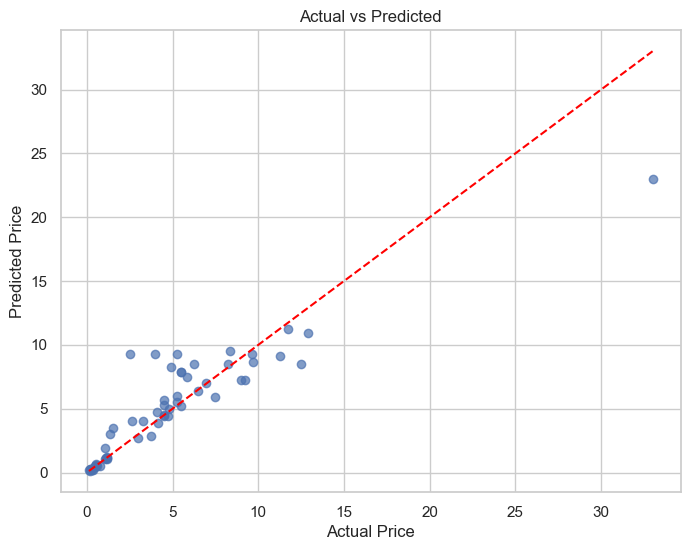

In [23]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

comparison_df = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred

})

display(comparison_df.head())

plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    y_pred,

    alpha=0.7

)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red",

    linestyle="--"

)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

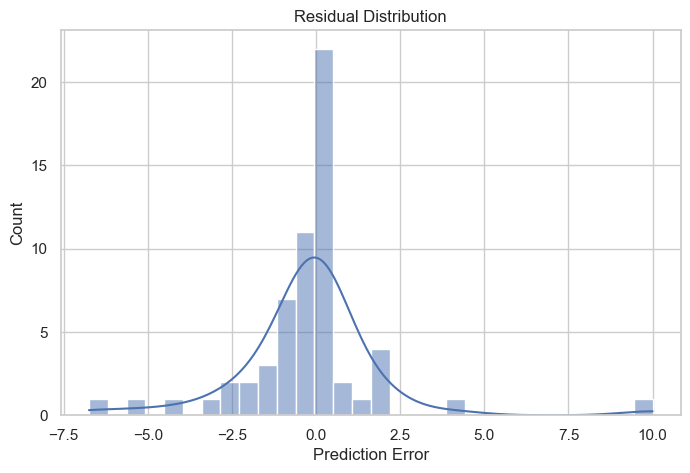

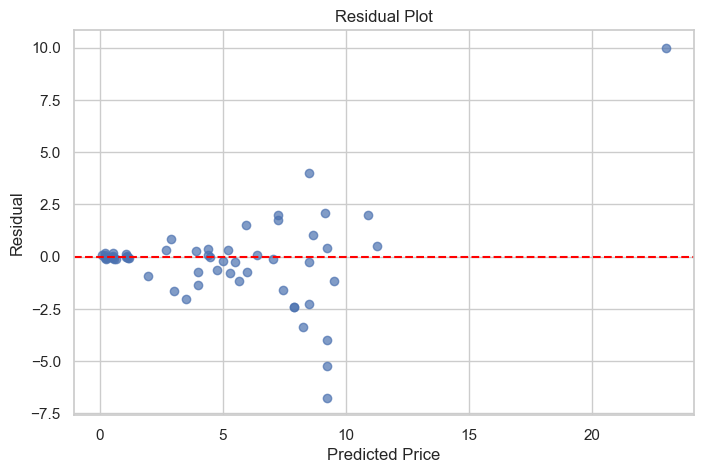

In [24]:
# ==========================================================
# Residual Analysis
# ==========================================================

residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(

    residuals,

    bins=30,

    kde=True

)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()

plt.figure(figsize=(8,5))

plt.scatter(

    y_pred,

    residuals,

    alpha=0.7

)

plt.axhline(

    0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

,Feature,Importance
0,Present_Price,0.918514
6,Car_Age,0.073779
1,Driven_kms,0.006633
4,Transmission,0.000743
3,Selling_type,0.000198
2,Fuel_Type,0.000133
5,Owner,0.000001


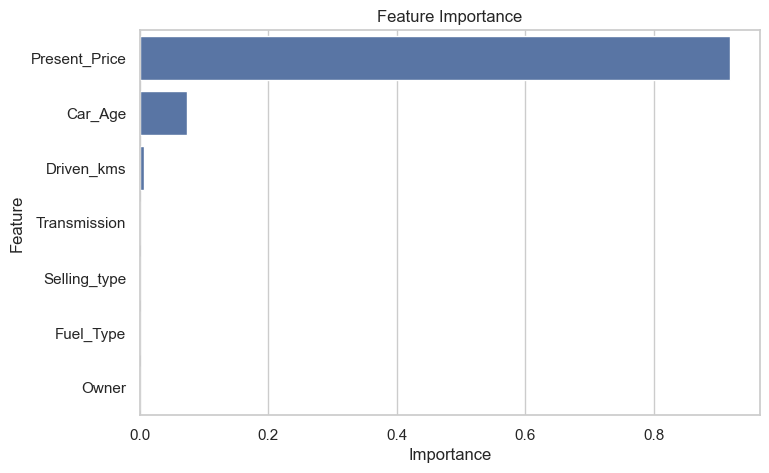

In [25]:
# ==========================================================
# Feature Importance
# ==========================================================

if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.DataFrame({

        "Feature": feature_columns,

        "Importance": best_model.feature_importances_

    })

    feature_importance = feature_importance.sort_values(

        by="Importance",

        ascending=False

    )

    display(feature_importance)

    plt.figure(figsize=(8,5))

    sns.barplot(

        data=feature_importance,

        x="Importance",

        y="Feature"

    )

    plt.title("Feature Importance")

    plt.show()

else:

    print("Feature importance not available for this model.")

In [26]:
# ==========================================================
# Cross Validation
# ==========================================================

cv_scores = cross_val_score(

    best_model,

    X,

    y,

    cv=5,

    scoring="r2"

)

print("Cross Validation Scores")

print(cv_scores)

print()

print("Average R² Score")

print(cv_scores.mean())

Cross Validation Scores
[ 0.90601812  0.66713794 -2.63098517  0.88225962  0.67020243]

Average R² Score
0.09892658905652656


In [27]:
# ==========================================================
# Save Model
# ==========================================================

joblib.dump(

    best_model,

    "models/car_price_model.pkl"

)

print("Model saved successfully.")

Model saved successfully.


In [28]:
# ==========================================================
# Save Label Encoders
# ==========================================================

joblib.dump(

    label_encoders,

    "models/label_encoders.pkl"

)

print("Encoders saved successfully.")

Encoders saved successfully.


In [29]:
# ==========================================================
# Save Feature Columns
# ==========================================================

joblib.dump(

    feature_columns,

    "models/feature_columns.pkl"

)

print("Feature columns saved.")

Feature columns saved.


In [30]:
# ==========================================================
# Save Metrics
# ==========================================================

model_metrics = {

    "algorithm": best_model_name,

    "r2": r2,

    "mae": mae,

    "mse": mse,

    "rmse": rmse,

    "cv_score": cv_scores.mean()

}

joblib.dump(

    model_metrics,

    "models/model_metrics.pkl"

)

print("Metrics saved.")

Metrics saved.


In [31]:
# ==========================================================
# Save Test Data
# ==========================================================

joblib.dump(

    X_test,

    "models/X_test.pkl"

)

joblib.dump(

    y_test,

    "models/y_test.pkl"

)

joblib.dump(

    y_pred,

    "models/y_pred.pkl"

)

print("Test data and predictions saved.")

Test data and predictions saved.


In [32]:
# ==========================================================
# Save Feature Importance
# ==========================================================

print("=" * 60)
print("Saving Feature Importance")
print("=" * 60)

if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.DataFrame({

        "Feature": feature_columns,

        "Importance": best_model.feature_importances_

    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    display(feature_importance)

    joblib.dump(
        feature_importance,
        "models/feature_importance.pkl"
    )

    print("Feature importance saved successfully.")

else:

    print("Selected model does not support feature importance.")

Saving Feature Importance


,Feature,Importance
0,Present_Price,0.918514
6,Car_Age,0.073779
1,Driven_kms,0.006633
4,Transmission,0.000743
3,Selling_type,0.000198
2,Fuel_Type,0.000133
5,Owner,0.000001


Feature importance saved successfully.


In [33]:
# ==========================================================
# Save Training Information
# ==========================================================

training_info = {

    "Dataset Shape": df.shape,

    "Training Samples": len(X_train),

    "Testing Samples": len(X_test),

    "Number of Features": len(feature_columns),

    "Features": feature_columns,

    "Best Model": best_model_name,

    "Cross Validation": float(cv_scores.mean()),

    "R2 Score": float(r2),

    "MAE": float(mae),

    "RMSE": float(rmse)

}

joblib.dump(

    training_info,

    "models/training_info.pkl"

)

print("Training information saved successfully.")

training_info

Training information saved successfully.


{'Dataset Shape': (299, 8),
 'Training Samples': 239,
 'Testing Samples': 60,
 'Number of Features': 7,
 'Features': ['Present_Price',
  'Driven_kms',
  'Fuel_Type',
  'Selling_type',
  'Transmission',
  'Owner',
  'Car_Age'],
 'Best Model': 'Decision Tree',
 'Cross Validation': 0.09892658905652656,
 'R2 Score': 0.8251682320558222,
 'MAE': 1.1478333333333333,
 'RMSE': 2.1227305528493248}

In [34]:
# ==========================================================
# Verify Saved Files
# ==========================================================

import os

print("=" * 60)
print("VERIFY SAVED FILES")
print("=" * 60)

files = [

    "car_price_model.pkl",

    "label_encoders.pkl",

    "feature_columns.pkl",

    "model_metrics.pkl",

    "feature_importance.pkl",

    "training_info.pkl",

    "X_test.pkl",

    "y_test.pkl",

    "y_pred.pkl"

]

for file in files:

    path = os.path.join("models", file)

    if os.path.exists(path):

        print(f"✅ {file}")

    else:

        print(f"❌ {file}")

print("\nVerification Completed.")

VERIFY SAVED FILES
✅ car_price_model.pkl
✅ label_encoders.pkl
✅ feature_columns.pkl
✅ model_metrics.pkl
✅ feature_importance.pkl
✅ training_info.pkl
✅ X_test.pkl
✅ y_test.pkl
✅ y_pred.pkl

Verification Completed.


In [38]:
# ==========================================================
# Sample Prediction
# ==========================================================

print("=" * 60)
print("Sample Prediction")
print("=" * 60)

sample = pd.DataFrame({

    "Present_Price": [5.50],

    "Driven_kms": [42000],

    "Fuel_Type": [

        label_encoders["Fuel_Type"].transform(["Petrol"])[0]

    ],

    "Selling_type": [

        label_encoders["Selling_type"].transform(["Dealer"])[0]

    ],

    "Transmission": [

        label_encoders["Transmission"].transform(["Manual"])[0]

    ],

    "Owner": [0],

    "Car_Age": [5]

})

display(sample)

prediction = best_model.predict(sample)

print()

print(f"Predicted Selling Price : ₹ {prediction[0]:.2f} Lakh")

Sample Prediction


,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,5.5,42000,2,0,1,0,5



Predicted Selling Price : ₹ 3.50 Lakh


In [39]:
# ==========================================================
# Project Summary
# ==========================================================

print("=" * 70)
print("🚗 CAR PRICE PREDICTION PROJECT COMPLETED")
print("=" * 70)

print(f"""
Dataset Shape           : {df.shape}

Training Samples        : {len(X_train)}

Testing Samples         : {len(X_test)}

Best Model              : {best_model_name}

R² Score                : {r2:.4f}

Cross Validation Score  : {cv_scores.mean():.4f}

Features Used           : {len(feature_columns)}

Model Saved             : models/car_price_model.pkl

Encoders Saved          : models/label_encoders.pkl

Metrics Saved           : models/model_metrics.pkl

Project Status          : READY FOR STREAMLIT 🚀
""")

print("=" * 70)
print("Notebook Execution Completed Successfully!")
print("=" * 70)

🚗 CAR PRICE PREDICTION PROJECT COMPLETED

Dataset Shape           : (299, 8)

Training Samples        : 239

Testing Samples         : 60

Best Model              : Decision Tree

R² Score                : 0.8252

Cross Validation Score  : 0.0989

Features Used           : 7

Model Saved             : models/car_price_model.pkl

Encoders Saved          : models/label_encoders.pkl

Metrics Saved           : models/model_metrics.pkl

Project Status          : READY FOR STREAMLIT 🚀

Notebook Execution Completed Successfully!
